In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import preprocessing
import pandas as pd

import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [41]:
def display_separation(data):
    pca = PCA(n_components=3)
    reduced_data = pca.fit_transform(data.drop("science_related", axis=1))

    reduced_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2', 'PC3'])
    reduced_df['science_related'] = data['science_related']

    fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(14, 6))
    #fig = plt.figure(figsize=(10, 7))
    ax1.axis('off')
    ax1 = fig.add_subplot(121, projection='3d')

    # Scatter plot
    scatter = ax1.scatter(reduced_df['PC1'], reduced_df['PC2'], reduced_df['PC3'], cmap= ListedColormap(['blue', 'orange']), c=reduced_df['science_related'], marker='o')

    ax1.set_xlabel('PC 1')
    ax1.set_ylabel('PC 2')
    ax1.set_zlabel('PC 3')
    ax1.set_title('Data Separation with PCA reduction')
    
    legend_labels = {1: 'Science Related', 0: 'Not Science Related'}
    # Create a custom legend
    handles = [
        mpatches.Patch(color='blue', label='Not Science Related'),
        mpatches.Patch(color='orange', label='Science Related')
    ]
    ax1.legend(handles=handles, title="Science Related")

    sns.scatterplot(x=reduced_df['PC1'], y=reduced_df['PC2'], hue=reduced_df['science_related'], ax=ax2)
    ax2.set_title('2D Scatter Plot (PC1 vs PC2)')
    ax2.set_xlabel('PC 1')
    ax2.set_ylabel('PC 2')

    plt.subplots_adjust(wspace=0.3)
    plt.show()

### Récupération des données issues des 2 prétraitements

In [42]:
data_pp1 = pd.read_csv("data_pp1.csv", sep=",", comment="#")
data_pp1 = data_pp1[~data_pp1['tokens'].isna()]
data_pp1.head()

,science_related,scientific_claim,scientific_reference,scientific_context,tokens,has_num,has_perc,has_url,has_emoji,has_mention,has_hash
0,0,0.0,0.0,0.0,knee bit sore guess sign recent treadmilling work,0,0,0,0,0,0
1,0,0.0,0.0,0.0,mcdonald breakfast stop then gym,0,0,0,1,0,0
2,1,1.0,0.0,0.0,gynecologist cancer experience explain danger ...,0,0,0,0,0,1
3,1,1.0,0.0,0.0,couch lock high lead sleep couch get stop do shit,0,0,0,0,0,0
4,1,1.0,0.0,0.0,daily routine help prevent problem bipolar dis...,0,0,1,0,0,0


In [43]:
data_pp2 = pd.read_csv("data_pp2.csv", sep=",", comment="#")
data_pp2 = data_pp2[~data_pp2['tokens'].isna()]
data_pp2.head()

,science_related,scientific_claim,scientific_reference,scientific_context,tokens
0,0,0.0,0.0,0.0,knee bit sore guess sign recent treadmilling work
1,0,0.0,0.0,0.0,mcdonald breakfast stop then gym emoticon emot...
2,1,1.0,0.0,0.0,gynecologist cancer experience explain danger ...
3,1,1.0,0.0,0.0,couch lock high lead sleep couch get stop do shit
4,1,1.0,0.0,0.0,daily routine help prevent problem bipolar dis...


# 1. Vectorization
## Vectorization avec TF-IDF

### Vectorization des données issue du premier prétraitement en 1-grams

In [44]:
vectorizer = TfidfVectorizer(ngram_range=(1,1))
vectorizer.fit(list(data_pp1['tokens']))

# creation du dataframe pour affichage
vectorized_pp1 = pd.DataFrame(
    data=vectorizer.transform(data_pp1['tokens']).toarray(),
    columns=vectorizer.get_feature_names_out()
)

vectorized_pp1["has_num"] = data_pp1["has_num"].reset_index(drop=True)
vectorized_pp1["has_perc"] = data_pp1["has_perc"].reset_index(drop=True)
vectorized_pp1["has_url"] = data_pp1["has_url"].reset_index(drop=True)
vectorized_pp1["has_emoji"] = data_pp1["has_emoji"].reset_index(drop=True)
vectorized_pp1["has_mention"] = data_pp1["has_mention"].reset_index(drop=True)
vectorized_pp1["has_hash"] = data_pp1["has_hash"].reset_index(drop=True)

scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(vectorized_pp1)
vectorized_pp1 = pd.DataFrame(scaled_array, columns=vectorized_pp1.columns)

vectorized_pp1["science_related"] = data_pp1["science_related"].reset_index(drop=True)

vectorized_pp1.head()

,aamiin,aap,ab,abah,abbotslangley,abdi,abeg,abetz,ability,able,...,ᵞᴼᵁ,ᶜᴴᴬᴿᴬᶜᵀᴱᴿ,逃げ恥,has_num,has_perc,has_url,has_emoji,has_mention,has_hash,science_related
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1


### Vectorization des données issues du second prétraitement en 1-gram

In [45]:
vectorizer = TfidfVectorizer(ngram_range=(1,1))
vectorizer.fit(list(data_pp2['tokens']))

vectorized_pp2 = pd.DataFrame(
    data=vectorizer.transform(data_pp2['tokens']).toarray(),
    columns=vectorizer.get_feature_names_out()
)

scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(vectorized_pp2)
vectorized_pp2 = pd.DataFrame(scaled_array, columns=vectorized_pp2.columns)

vectorized_pp2["science_related"] = data_pp2["science_related"].reset_index(drop=True)
vectorized_pp2.head()

,aamiin,aap,ab,abah,abbotslangley,abdi,abeg,abetz,ability,able,...,özil,ᴶᴼᴷᴱˢ,ᴸᴵᴱᴰ,ᴸᴼᵛᴱ,ᴼᴼᴴ,ᵀᴴᴵˢ,ᵞᴼᵁ,ᶜᴴᴬᴿᴬᶜᵀᴱᴿ,逃げ恥,science_related
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


## Séparation des données après vectorization

### Prétraitement 1

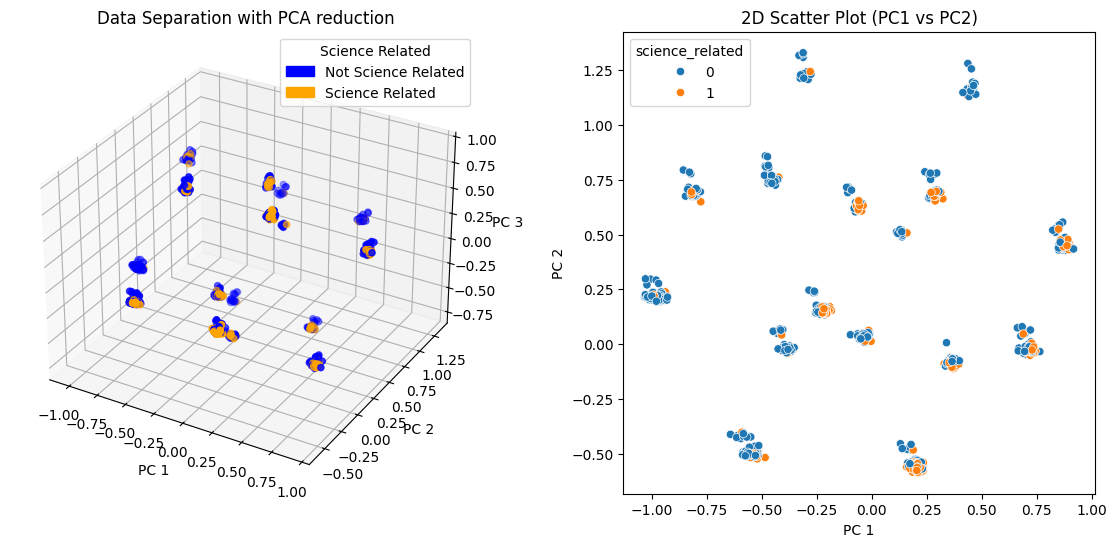

In [46]:
display_separation(vectorized_pp1)

### Prétraitment 2

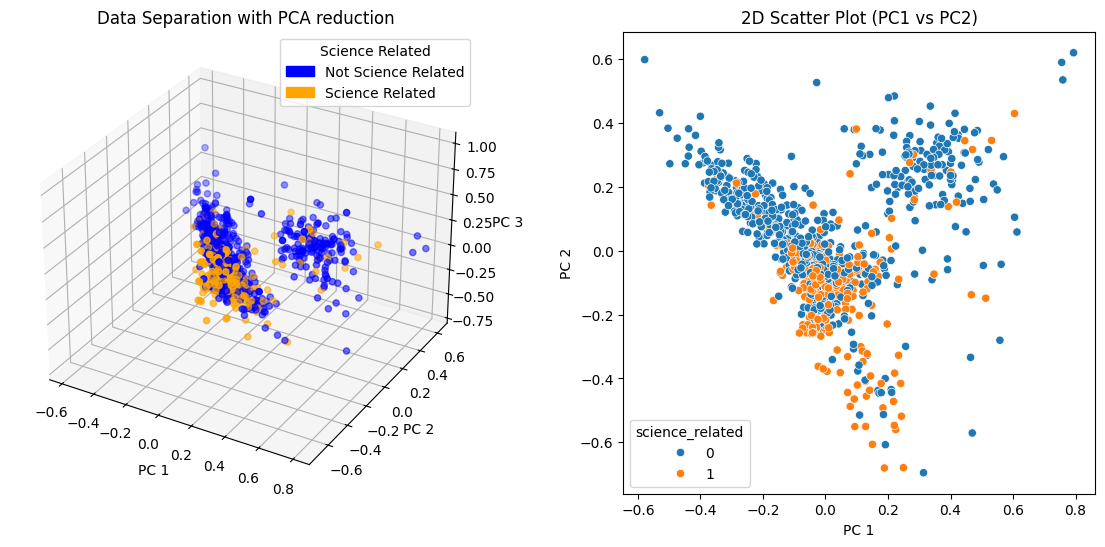

In [47]:
display_separation(vectorized_pp2)

# 2. Entrainement 

## Précision sur les deux jeux de données

### Précision sur le premier prétraitement

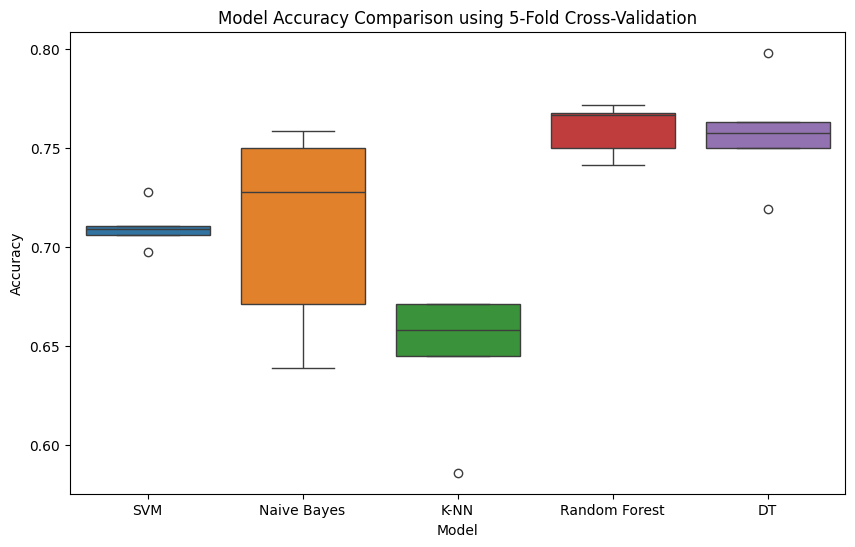

In [48]:
# Assuming 'df' is your DataFrame, with features and the target label column
# Replace 'target_column' with the actual name of your label column
X = vectorized_pp1.drop(columns=['science_related'])  # Features
y = vectorized_pp1['science_related']  # Labels

# Initialize classifiers
models = {
    'SVM': SVC(random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-NN': KNeighborsClassifier(),
    'DT': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Initialize StratifiedKFold for 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store the accuracy for each model
accuracies = {'SVM': [], 'Naive Bayes': [], 'K-NN': [], 'Random Forest': []}

# Perform 5-fold cross-validation for each model
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    accuracies[model_name] = cv_scores

# Create a DataFrame for plotting
accuracy_df = pd.DataFrame(accuracies)

# Plot the boxplot for accuracy distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=accuracy_df)
plt.title('Model Accuracy Comparison using 5-Fold Cross-Validation')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.show()

### Précision sur le deuxième prétraitement

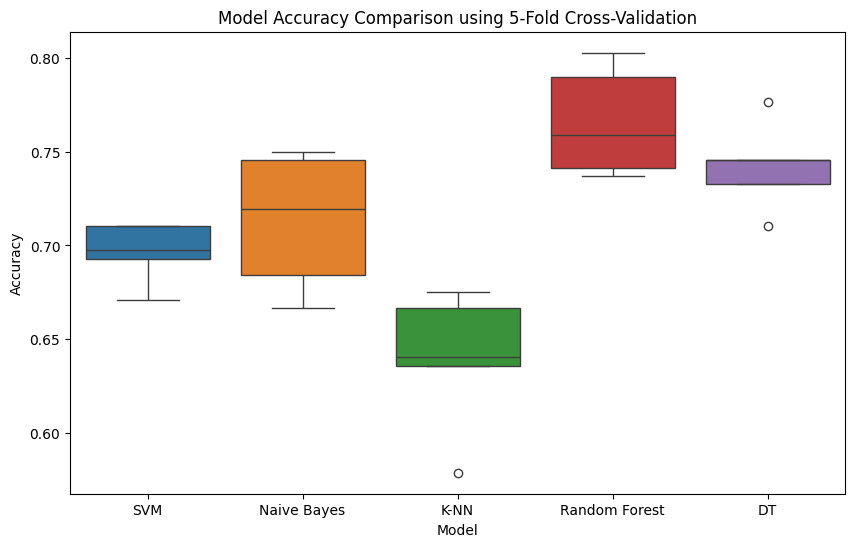

In [49]:
# Assuming 'df' is your DataFrame, with features and the target label column
# Replace 'target_column' with the actual name of your label column
X = vectorized_pp2.drop(columns=['science_related'])  # Features
y = vectorized_pp2['science_related']  # Labels

# Initialize classifiers
models = {
    'SVM': SVC(random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-NN': KNeighborsClassifier(),
    'DT': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Initialize StratifiedKFold for 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store the accuracy for each model
accuracies = {'SVM': [], 'Naive Bayes': [], 'K-NN': [], 'Random Forest': []}

# Perform 5-fold cross-validation for each model
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    accuracies[model_name] = cv_scores

# Create a DataFrame for plotting
accuracy_df = pd.DataFrame(accuracies)

# Plot the boxplot for accuracy distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=accuracy_df)
plt.title('Model Accuracy Comparison using 5-Fold Cross-Validation')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.show()

# 3. Sauvegarde de la vectorization

Le second prétraitement montre de meilleurs résultats

In [50]:
with open("vectorized.csv", "w") as f:
    vectorized_pp2.to_csv(f, index=False)